# Resampling-Based Tuning on 1D Exponential Data

Use this notebook with the `flk_torch113_cu116` environment. It generates a truncated exponential reference sample with `data.sample_ref_exp`, fixes `sigma` from the reference pairwise-distance scale, scans `lambda` and `M` with the resampling-based tuning workflow, and saves inspection plots. The notebook does not choose a working point.

In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data").is_dir() and (candidate / "tuning").is_dir():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data import sample_ref_exp
importlib.invalidate_caches()
for module_name in (
    "tuning.resampling_scan",
    "tuning",
    "stat_tests.resampling",
    "stat_tests",
):
    sys.modules.pop(module_name, None)
from tuning import (
    nplm_resampling_hyperparameter_scan,
    plot_average_test_statistic,
    plot_average_test_statistic_heatmap,
    plot_training_time,
    save_scan_plots,
)

print(f"Repository root: {REPO_ROOT}")

/data/marcol/anaconda3/envs/flk_torch113_cu116/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository root: /home/marcol/kernel-nplm


## Scan Settings

The defaults below are intentionally small. Increase the pool size, sample sizes, grid, and solver iterations once the workflow is behaving as expected.

In [14]:
SEED = 123

# Truncated exponential reference distribution from data.synthetic.sample_ref_exp.
RATE = 8.0
XMAX = 1.0
N_REFERENCE_POOL = 100_0000

# Resampling-toy sizes. The scan computes N_TRIALS statistics per grid point.
N_REF = 10000
N_DATA = 1000
N_TRIALS = 100
POISSON_FLUCTUATE_N_DATA = True
PAIRED_TOYS = False

# Fixed sigma from reference pairwise distances, following the paper's tuning prescription.
SIGMA_PERCENTILE = 90.0
SIGMA_MAX_POINTS = 2_000

# Grid to inspect manually.
LAMBDA_VALUES = [1e-4, 1e-5, 1e-6, 1e-7]
M_VALUES = [30, 60, 100, 500, 1000]

# Solver/execution settings. For GPU runs, switch cpu=False and keops='yes'.
MODEL_ITERATIONS = [100000]
CG_TOL = float(np.sqrt(1e-7))
USE_CPU = False
KEOPS = "yes"

OUTPUT_DIR = REPO_ROOT / "results_tuning_1d_exp_unpaired"

Reference pool shape: (1000000, 1)
Reference range: [0.0000, 0.9999]


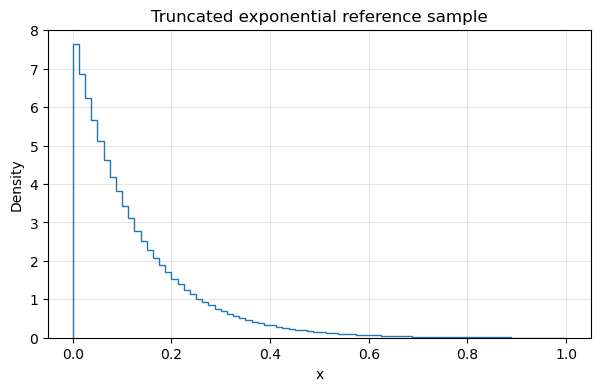

In [9]:
rng = np.random.default_rng(SEED)
x_ref_pool = sample_ref_exp(
    N_REFERENCE_POOL,
    rate=RATE,
    xmax=XMAX,
    rng=rng,
).reshape(-1, 1)

print(f"Reference pool shape: {x_ref_pool.shape}")
print(f"Reference range: [{x_ref_pool.min():.4f}, {x_ref_pool.max():.4f}]")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_ref_pool[:, 0], bins=80, histtype="step", density=True)
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Truncated exponential reference sample")
ax.grid(True, alpha=0.3)
plt.show()

In [10]:
def estimate_distance_percentile(x, percentile, max_points, rng):
    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if x.shape[0] > max_points:
        idx = rng.choice(x.shape[0], size=max_points, replace=False)
        x = x[idx]
    distances = pdist(np.ascontiguousarray(x))
    return float(np.percentile(distances, percentile))


sigma_rng = np.random.default_rng(SEED + 1)
sigma = estimate_distance_percentile(
    x_ref_pool,
    percentile=SIGMA_PERCENTILE,
    max_points=SIGMA_MAX_POINTS,
    rng=sigma_rng,
)

model_config = {
    "sigma": sigma,
    "NR": float(N_DATA),
    "iter": MODEL_ITERATIONS,
    "cg_tol": CG_TOL,
    "cpu": USE_CPU,
    "keops": KEOPS,
    "verbose": 0,
}

print(f"sigma ({SIGMA_PERCENTILE:g}th percentile distance): {sigma:.6g}")
model_config

sigma (90th percentile distance): 0.294285


{'sigma': 0.29428453453125253,
 'NR': 1000.0,
 'iter': [100000],
 'cg_tol': 0.00031622776601683794,
 'cpu': False,
 'keops': 'yes',
 'verbose': 0}

## Run The Scan

This calls `nplm_resampling_test` for every `(lambda, M)` point. Set `PAIRED_TOYS=True` to make each grid point see the same resampled null toys, which makes the curves easier to compare by eye. If `POISSON_FLUCTUATE_N_DATA=True`, each null toy draws its realized pseudo-data count from `Poisson(N_DATA)` while `NR` remains the expected count used in the NPLM weight.

In [11]:
scan = nplm_resampling_hyperparameter_scan(
    x_ref_pool,
    model_config,
    lambda_values=LAMBDA_VALUES,
    m_values=M_VALUES,
    n_ref=N_REF,
    n_data=N_DATA,
    n_trials=N_TRIALS,
    null_sampling="disjoint",
    poisson_fluctuate_n_data=POISSON_FLUCTUATE_N_DATA,
    seed=SEED,
    paired_toys=PAIRED_TOYS,
    resample_nystrom=True,
    reference_factor_warning_threshold=5.0,
    progress=True,
)

print(f"Raw rows: {len(scan.raw_results)}")
print(f"Summary rows: {len(scan.summary)}")

[tuning] lambda=0.0001 M=30 trials=100 seed=66316748
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-04 - sub-iterations 100000
Ite

In [12]:
try:
    import pandas as pd

    summary_table = pd.DataFrame(scan.summary)
    display(summary_table)
except ImportError:
    scan.summary

,lambda,M,n_trials,t_mean,t_std,t_sem,n_data_mean,n_data_std,elapsed_sec,time_per_trial_sec
0,1.000000e-07,30,100,7.089561,3.685364,0.368536,1007.01,28.700296,24.762466,0.247625
1,1.000000e-07,60,100,7.641957,4.144813,0.414481,997.86,32.477193,24.369309,0.243693
2,1.000000e-07,100,100,7.476629,3.329679,0.332968,1002.32,30.655097,22.987850,0.229879
3,1.000000e-07,500,100,8.513905,4.488764,0.448876,1001.27,33.934237,17.737358,0.177374
4,1.000000e-07,1000,100,8.773040,4.293672,0.429367,1002.00,34.001485,20.303689,0.203037
5,1.000000e-06,30,100,6.940487,3.735509,0.373551,1003.26,35.216967,20.559814,0.205598
6,1.000000e-06,60,100,7.461748,4.012172,0.401217,1001.43,35.210265,20.022547,0.200225
7,1.000000e-06,100,100,6.952112,3.968651,0.396865,1003.92,31.354822,18.360551,0.183606
8,1.000000e-06,500,100,7.256050,3.902258,0.390226,997.06,31.434980,15.324257,0.153243
9,1.000000e-06,1000,100,6.912769,3.128892,0.312889,1003.45,29.520879,18.487344,0.184873


## Inspection Plots

The third plot tracks the measured average wall time per null toy for each scan point.

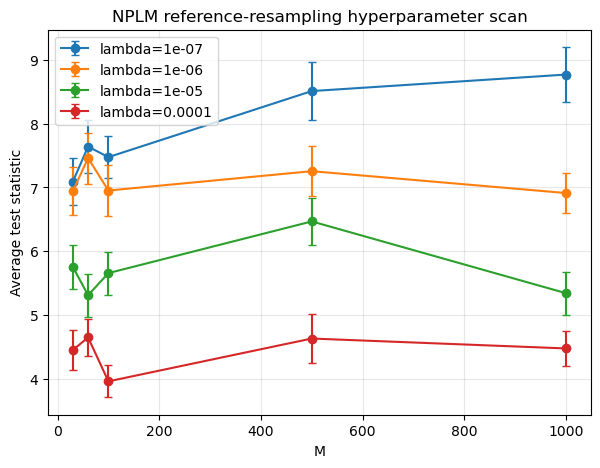

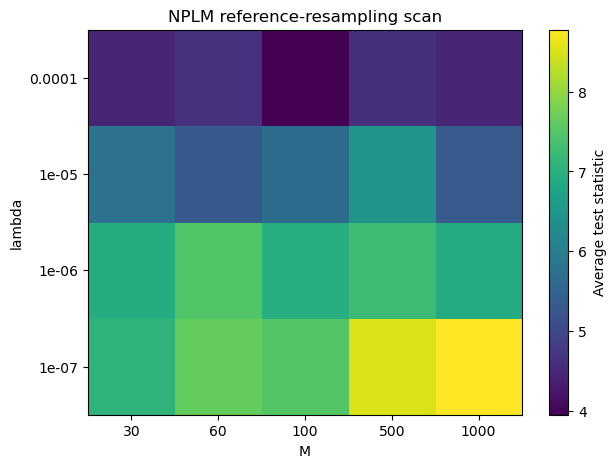

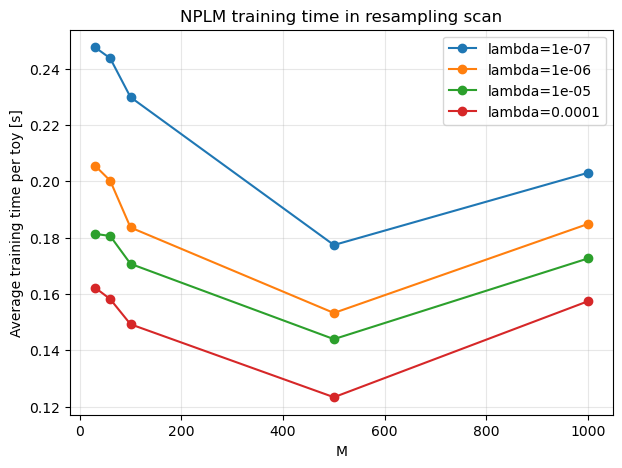

In [13]:
fig, ax = plot_average_test_statistic(scan, include_sem=True, logx=False)
plt.show()

fig, ax = plot_average_test_statistic_heatmap(scan)
plt.show()

fig, ax = plot_training_time(scan, logx=False)
plt.show()

In [15]:
plot_paths = save_scan_plots(
    scan,
    OUTPUT_DIR,
    prefix="exp1d_resampling_tuning",
    include_sem=True,
    logx=False,
)

summary_path = OUTPUT_DIR / "exp1d_resampling_tuning_summary.json"
summary_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "settings": {
        "seed": SEED,
        "rate": RATE,
        "xmax": XMAX,
        "n_reference_pool": N_REFERENCE_POOL,
        "n_ref": N_REF,
        "n_data": N_DATA,
        "n_trials": N_TRIALS,
        "poisson_fluctuate_n_data": POISSON_FLUCTUATE_N_DATA,
        "paired_toys": PAIRED_TOYS,
        "sigma_percentile": SIGMA_PERCENTILE,
        "sigma": sigma,
        "lambda_values": LAMBDA_VALUES,
        "m_values": M_VALUES,
        "model_config": model_config,
    },
    "summary": scan.summary,
    "raw_results": scan.raw_results,
}
with summary_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved plots:")
for name, path in plot_paths.items():
    print(f"  {name}: {path}")
print(f"Saved summary: {summary_path}")

Saved plots:
  average_statistic: /home/marcol/kernel-nplm/results_tuning_1d_exp_unpaired/exp1d_resampling_tuning_average_statistic_vs_m.png
  average_statistic_heatmap: /home/marcol/kernel-nplm/results_tuning_1d_exp_unpaired/exp1d_resampling_tuning_average_statistic_heatmap.png
  training_time: /home/marcol/kernel-nplm/results_tuning_1d_exp_unpaired/exp1d_resampling_tuning_training_time_vs_m.png
Saved summary: /home/marcol/kernel-nplm/results_tuning_1d_exp_unpaired/exp1d_resampling_tuning_summary.json


Inspect the plots and summary table to choose the working point manually. A separate suggestion layer can be added later without changing this scan notebook.